## Problem Statement
According to the news report, the total number of accidents that we have had in Kenya as of 2025 was 4458. https://www.citizen.digital/article/ntsa-reports-spike-in-road-fatalities-as-2025-death-toll-hits-4458-n374206. The rise of road accidents on Kenya Roads often happen due to a chain of small warnings ignored such as vehicle condition, weather, driver behaviour, speed, traffic density, condition of roads, positioning of road signs and time of day, driver experience, drug & alcohol usage, smartphone usage, location of accidents.

# Goal of the project
1) Prepare the dataset for binary classification
2) Create a logistic regression model to predict accident occurence
3) Explain model predictions using odds ratio.

A) Prepare Data : Import- Binary target, Explore: Class balance, Split: Randomized train-test split 
B) Build model - Baseline- Accuracy score, Iterate- Logistic regression, Evaluate: accuracy score
C) Communicate results - Odds ratio.

## Preparation of Data

In [28]:
# import the dataframe
import pandas as pd
import numpy as np

# visualizations
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# splitting of data
from sklearn.model_selection import train_test_split
from category_encoders import OneHotEncoder
from sklearn.impute import SimpleImputer

# training the model with data
from sklearn.pipeline import make_pipeline
# from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
# from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from data import Repository
# save the model after training and tuning
import pickle

### Create a wrangle function to import the excel file and convert it into a dataframe

In [31]:
repo = Repository("Road_Safety_Survey_ShortNames.xlsx")
df = repo.wrangle()
df.head()

,AgeGrp,Gender,YrsDrive,DriveFreq,VehType,OVC,HESL,HPhone,HBrake,HDistract,...,RoadCond,Lighting,Weather,DriveTime,TrafficLvl,SignVis,County,Latitude,Longitude,AccOccur
0,19,Female,1,2.0,Car,3,2,1,Never,Never,...,Fair,1.0,Clear,Daytime,Moderate,NaN,NaN,NaN,NaN,0
1,18,Male,0,5.0,Motorcycle,4,2,2,Rarely,Rarely,...,Fair,2.0,Dusty,Early morning,Moderate,Adequate,NaN,NaN,NaN,0
2,22,Male,4,NaN,Car,3,3,3,Rarely,Rarely,...,Fair,1.0,Clear,Evening,Heavy,Poor,NaN,NaN,NaN,1
3,21,Female,3,NaN,Car,3,1,1,Never,Rarely,...,Fair,NaN,NaN,Early morning,Moderate,Very poor (signs are missing or unclear),Nakuru,-0.3031,36.0800,0
4,21,Male,3,2.0,Car,3,1,1,Rarely,Never,...,Fair,1.0,Dusty,Evening,Moderate,Poor,Nairobi,-1.2921,36.8219,1


In [266]:
df.shape

(1014, 24)

In [284]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AgeGrp        1014 non-null   int64  
 1   Gender        1014 non-null   object 
 2   YrsDrive      1014 non-null   int64  
 3   DriveFreq     719 non-null    float64
 4   VehType       1014 non-null   object 
 5   LastService   1014 non-null   object 
 6   OVC           1014 non-null   int64  
 7   HESL          1014 non-null   int64  
 8   HPhone        1014 non-null   int64  
 9   HBrake        1014 non-null   object 
 10  HDistract     1014 non-null   object 
 11  SleepHrs      99 non-null     float64
 12  Alcohol6h     113 non-null    float64
 13  DriveEnv      1014 non-null   object 
 14  RoadCond      1014 non-null   int64  
 15  Lighting      838 non-null    float64
 16  Weather       942 non-null    float64
 17  DriveTime     1014 non-null   object 
 18  TrafficLvl    1014 non-null 

# Data Wrangling 
## the following columns need to be converted to int/ float to allow the model to generalize well
1) Age group should be divided according to the normal distribution ✔️
2) Yrs driven should be a number since you can get the number of years you had a license ecitizen ✔️
3) DriveFrequency should also be a scale where barely is 1 and occasionally 5 ✔️
4) vehicle age should be a number since the log book has the manufacturing date ✔️
5) overall vehicle condition should be converted to a scale where 1 is fair, 2 is good and 3 is excellent ✔️
6) hesl speed limit & hphone exceeding should also be a range from 1 to 5 ✔️
7) sleephrs should be a number between 4 and 8 hours ✔️
8) convert tired month from yes & no to 1 or 0, 1 for yes and 0 for no ✔️
9) have you ever drunk driven no to be 0 and prefer not to say or yes to be 1 ✔️
10) medicalert no to be 0 and 1 to be yes ✔️
11) Typical road condition bad to be 1, fair to be 2, good to be 3, excellent to be 4 ✔️- important feature
12) road lighting quality poor to be 1, fair to be 2, good to be 3, excellent to be 4 ✔️- important feature
13) typical traffic level heavy is a 3, moderate is a 2, low is a 1 ✔️
14) how would you rate visibility and clarity very poor 1, poor 2, adequate 3, good 4, very good 5 ✔️

In [168]:
# lets change the age group using the demographic data: keep in mind; 
# 18-25 are 15% (26-35) are 61%, 45-55 are 4% and 35-45 are 20%
# create a function to populate the agegrp column
import random
random.seed(42)
groupA_num = int(1014 * 0.15)
groupB_num = int(1014 * 0.61)
groupC_num = int(1014 * 0.20) + 1
groupD_num = int(1014 * 0.04) + 1

groupA = (18, 25)
groupB = (26, 35)
groupC = (36, 45)
groupD = (46, 55)
AgeGrp = []
def generate_age_group(group_size, age_range):
    min_age, max_age = age_range
    return[random.randint(min_age, max_age) for _ in range(group_size)]

AgeGrp = []
AgeGrp.extend(generate_age_group(groupA_num, groupA))
AgeGrp.extend(generate_age_group(groupB_num, groupB))
AgeGrp.extend(generate_age_group(groupC_num, groupC))
AgeGrp.extend(generate_age_group(groupD_num, groupD))

print(len(AgeGrp))
print(AgeGrp[:20])

df["AgeGrp"] = AgeGrp

1014
[19, 18, 22, 21, 21, 20, 19, 19, 24, 18, 18, 19, 21, 21, 18, 21, 24, 21, 25, 22]


In [177]:
# Yrs driven should be a number since you can get the number of years you had a license ecitizen
set_age = 18
mask = df["AgeGrp"] - set_age
mask.head()
df["YrsDrive"] = mask
df.head()

,AgeGrp,Gender,YrsDrive,LicenseType,DriveFreq,VehType,VehAge,LastService,OVC,HESL,...,RushHours,Accident5y,AccCause,RiskSelf,Preventable,TrainingType,SignVis,County,VehCondition,AccOccur
0,19,Male,1,Private,Occasionally,Car,More than 10 years,Within 3 months,Good,Rarely,...,Yes,No,NaN,Low,Yes,Driving school – basic training,NaN,NaN,NaN,0
1,18,Male,0,Commercial,Daily,Motorcycle,5-10 years,Within 3 months,Excellent,Rarely,...,NaN,No,Other,Very low,Yes,Professional/commercial driving training,Adequate,NaN,NaN,0
2,22,Male,4,Private,Rarely,Car,More than 10 years,More than 6 months ago,Good,Sometimes,...,No,Yes,Other,Moderate,Yes,Driving school – basic training,Poor,NaN,NaN,1
3,21,Male,3,NaN,Rarely,Car,Less than 5 years,3–6 months ago,Good,Never,...,Yes,No,NaN,Low,Yes,Formal training (self-taught / informal),Very poor (signs are missing or unclear),Nakuru,NaN,0
4,21,Male,3,Private,Occasionally,Car,5-10 years,Not sure,Good,Never,...,No,Yes,Road condition,Moderate,Yes,Driving school – basic training,Poor,Nairobi,NaN,1


In [182]:
# DriveFrequency should also be a scale where barely is 1 and occasionally 5
DriveFreq = {
    "Daily" : 5,
    "Several Times a week" : 3,
    "Occasionally" : 2,
    " Rarely" : 1
}

df["DriveFreq"] = df["DriveFreq"].map(DriveFreq)
df["DriveFreq"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1014 entries, 0 to 1013
Series name: DriveFreq
Non-Null Count  Dtype  
--------------  -----  
0 non-null      float64
dtypes: float64(1)
memory usage: 8.1 KB


In [183]:
# vehicle age should be a number since the log book has the manufacturing date
vehicleAge = {
    "Less than 5 years": 3,
    "5-10 years": 7,
    "More than 10 years": 12
}
df["VehAge"] = df["VehAge"].map(vehicleAge)
df["VehAge"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1014 entries, 0 to 1013
Series name: VehAge
Non-Null Count  Dtype
--------------  -----
1014 non-null   int64
dtypes: int64(1)
memory usage: 8.1 KB


In [184]:
# overall vehicle condition should be converted to a scale where 1 is fair, 2 is good and 3 is excellent
OverallVehicle = {
    "Poor" : 1,
    "Fair" : 2,
    "Good" : 3,
    "Excellent" : 4
}

df["OVC"] = df["OVC"].map(OverallVehicle)

In [187]:
# hesl speed limit & hphone exceeding should also be a range from 1 to 5
speed_phone = {
    "Never" : 1,
    "Rarely" : 2,
    "Sometimes": 3,
    "Often" : 4
}

df["HESL"] = df["HESL"].map(speed_phone)
df["HPhone"] = df["HPhone"].map(speed_phone)
df.head()

,AgeGrp,Gender,YrsDrive,LicenseType,DriveFreq,VehType,VehAge,LastService,OVC,HESL,...,RushHours,Accident5y,AccCause,RiskSelf,Preventable,TrainingType,SignVis,County,VehCondition,AccOccur
0,19,Male,1,Private,NaN,Car,12,Within 3 months,3,2,...,Yes,No,NaN,Low,Yes,Driving school – basic training,NaN,NaN,NaN,0
1,18,Male,0,Commercial,NaN,Motorcycle,7,Within 3 months,4,2,...,NaN,No,Other,Very low,Yes,Professional/commercial driving training,Adequate,NaN,NaN,0
2,22,Male,4,Private,NaN,Car,12,More than 6 months ago,3,3,...,No,Yes,Other,Moderate,Yes,Driving school – basic training,Poor,NaN,NaN,1
3,21,Male,3,NaN,NaN,Car,3,3–6 months ago,3,1,...,Yes,No,NaN,Low,Yes,Formal training (self-taught / informal),Very poor (signs are missing or unclear),Nakuru,NaN,0
4,21,Male,3,Private,NaN,Car,7,Not sure,3,1,...,No,Yes,Road condition,Moderate,Yes,Driving school – basic training,Poor,Nairobi,NaN,1


In [188]:
# sleephrs should be a number between 4 and 8 hours
sleephrs = {
    "less than 4 hours" : 3,
    "4-6 hours" : 5,
    "6-8 hours" : 7,
    "More than 8 hours" : 9
}
df["SleepHrs"] = df["SleepHrs"].map(sleephrs)
df["SleepHrs"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1014 entries, 0 to 1013
Series name: SleepHrs
Non-Null Count  Dtype  
--------------  -----  
99 non-null     float64
dtypes: float64(1)
memory usage: 8.1 KB


In [189]:
# convert tired month from yes & no to 1 or 0, 1 for yes and 0 for no
tiredMonth = {
    "yes" : 1,
    "no" : 0
}

df["TiredMonth"] = df["TiredMonth"].map(tiredMonth)
df["TiredMonth"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1014 entries, 0 to 1013
Series name: TiredMonth
Non-Null Count  Dtype  
--------------  -----  
0 non-null      float64
dtypes: float64(1)
memory usage: 8.1 KB


In [190]:
# have you ever drunk driven no to be 0 and prefer not to say or yes to be 1
drunkdriven = {
    "yes" : 1,
    "no" : 0,
    "Prefer not to say" : 1
}
df["Alcohol6h"] = df["Alcohol6h"].map(drunkdriven)
df["Alcohol6h"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1014 entries, 0 to 1013
Series name: Alcohol6h
Non-Null Count  Dtype  
--------------  -----  
113 non-null    float64
dtypes: float64(1)
memory usage: 8.1 KB


In [191]:
# medicalert no to be 0 and 1 to be yes
medication = {
    "yes" : 1,
    "no" : 0,
    "Not sure" : 1
}

df["MedsAlert"] = df["MedsAlert"].map(medication)
df["MedsAlert"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1014 entries, 0 to 1013
Series name: MedsAlert
Non-Null Count  Dtype  
--------------  -----  
0 non-null      float64
dtypes: float64(1)
memory usage: 8.1 KB


In [192]:
# Typical road condition bad to be 1, fair to be 2, good to be 3, excellent to be 4
roadCon = {
    "Poor": 1,
    "Fair" : 2,
    "Good" : 3
    
}

df["RoadCond"] = df["RoadCond"].map(roadCon)
df["RoadCond"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1014 entries, 0 to 1013
Series name: RoadCond
Non-Null Count  Dtype
--------------  -----
1014 non-null   int64
dtypes: int64(1)
memory usage: 8.1 KB


In [193]:
# road lighting quality poor to be 1, fair to be 2, good to be 3, excellent to be 4
roadLight = {
    "Poor": 1,
    "None" : 0,
    "Good" : 2
    
}

df["Lighting"] = df["Lighting"].map(roadLight)
df["Lighting"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1014 entries, 0 to 1013
Series name: Lighting
Non-Null Count  Dtype  
--------------  -----  
838 non-null    float64
dtypes: float64(1)
memory usage: 8.1 KB


In [194]:
# typical traffic level heavy is a 3, moderate is a 2, low is a 1
weather = {
    "Clear" : 1,
    "Rainy" : 2,
    "Foggy" : 3,
    "Dusty" :4
}
df["Weather"] = df["Weather"].map(weather)
# how would you rate visibility and clarity very poor 1, poor 2, adequate 3, good 4, very good 5
visibility = {
    "Very poor (signs are missing or unclear)" : 1,
    "Poor" : 2,
    "Adequate" : 3,
    "Good" : 4,
    "Very good (clear and easy to follow)" : 5 
}
df["SignVis"] = df["SignVis"].map(visibility)

In [210]:
# male drivers are 80% and female drivers are 20 %
total_rows = len(df)
male_count = int(total_rows * 0.8)
female_count = total_rows - male_count

genders = ["Male"] * male_count + ["Female"] * female_count
random.shuffle(genders)
df["Gender"] = genders

In [186]:
df.columns

Index(['AgeGrp', 'Gender', 'YrsDrive', 'LicenseType', 'DriveFreq', 'VehType',
       'VehAge', 'LastService', 'OVC', 'HESL', 'HPhone', 'HBrake', 'HDistract',
       'SeatBelt', 'SleepHrs', 'TiredMonth', 'Alcohol6h', 'MedsAlert',
       'DriveEnv', 'RoadCond', 'Lighting', 'Weather', 'DriveTime',
       'TrafficLvl', 'RushHours', 'Accident5y', 'AccCause', 'RiskSelf',
       'Preventable', 'TrainingType', 'SignVis', 'County', 'VehCondition',
       'AccOccur'],
      dtype='object')

In [205]:
df.columns

Index(['AgeGrp', 'Gender', 'YrsDrive', 'DriveFreq', 'VehType', 'VehAge',
       'LastService', 'OVC', 'HESL', 'HPhone', 'HBrake', 'HDistract',
       'SleepHrs', 'TiredMonth', 'Alcohol6h', 'MedsAlert', 'DriveEnv',
       'RoadCond', 'Lighting', 'Weather', 'DriveTime', 'TrafficLvl',
       'RushHours', 'Accident5y', 'TrainingType', 'SignVis', 'County'],
      dtype='object')

In [30]:
# I want to build a binary classification model but our current target "Accident5y" has yes and no as categories. I need to convert them to 1's and 0's
acc_involve = {
    "Yes" : 1,
    "No" : 0
}
# create a new column that indicates whether an accident occured or not
df["AccOccur"] = df["Accident5y"].map(acc_involve)
df["AccOccur"].head()

0    0
1    0
2    1
3    0
4    1
Name: AccOccur, dtype: int64

In [16]:
## Drop leaky columns
drop_cols.append("Accident5y")

In [101]:
df["Accident5y"].unique()

array(['No', 'Yes'], dtype=object)

In [19]:
## Drop high and low cardinatlity columns
drop_cols = ["TS", "ConsentStudy", "ConsentProceed"]

In [48]:
# dropping the column with the least data points
df["AccCount"].value_counts()

AccCount
1      84
2–3    35
1       4
Name: count, dtype: int64

In [42]:
# Only fill the missing (NaN) values - very safe & common approach

proportions = df['OVC'].value_counts(normalize=True)

# Where is NaN → we fill
mask_missing = df['OVC'].isna()

df.loc[mask_missing, 'OVC'] = np.random.choice(
    proportions.index,
    size=mask_missing.sum(),
    p=proportions.values
)

# Exploratory Data Analysis

<Axes: title={'center': 'Accident Count Balance'}, xlabel='Count', ylabel='Relative Frequency'>

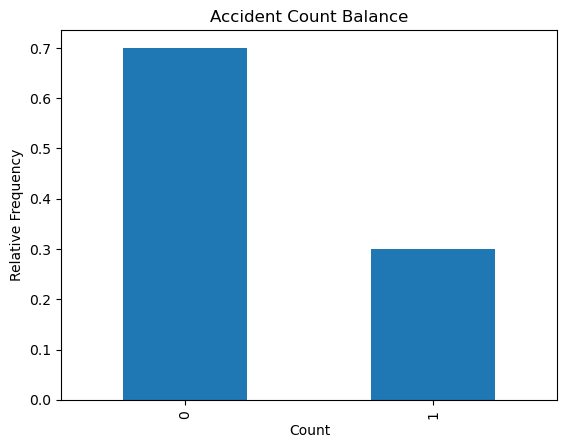

In [56]:
# create a hist to show the distribution of AccOccur with age group
df["AccOccur"].value_counts(normalize=True).plot(kind="bar", xlabel="Count", ylabel="Relative Frequency", title="Accident Count Balance");

the distribution of those people who have seen accidents vs those who haven't is unbalanced.

In [107]:
df["AccOccur"].value_counts(normalize=True)

AccOccur
0    0.700197
1    0.299803
Name: proportion, dtype: float64

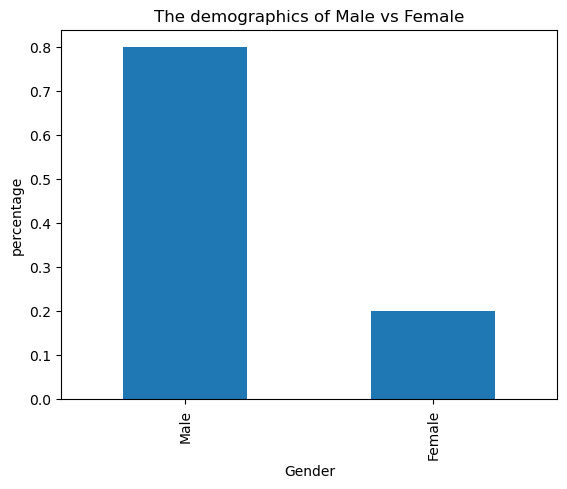

In [229]:
# bar chart of male and female drivers
df["Gender"].value_counts(normalize=True).plot(
    kind="bar"
)
plt.ylabel("percentage")
plt.title("The demographics of Male vs Female");

From the bar graph, we can conclude that the number of male drivers is higher than the number of female drivers

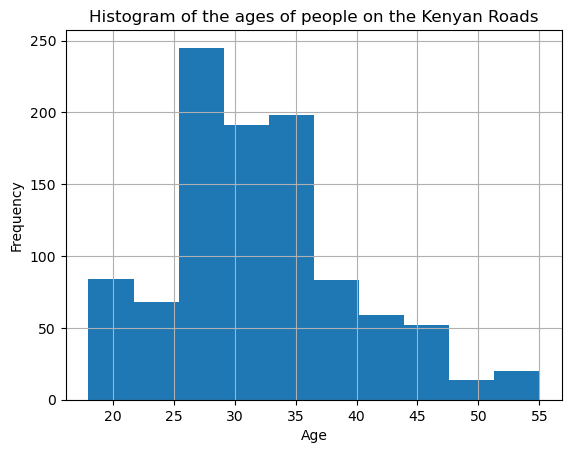

In [228]:
# histogram of age
df["AgeGrp"].hist()
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Histogram of the ages of people on the Kenyan Roads");

from this histogram we can deduce that most of the drivers are between the ages of 25 and 40

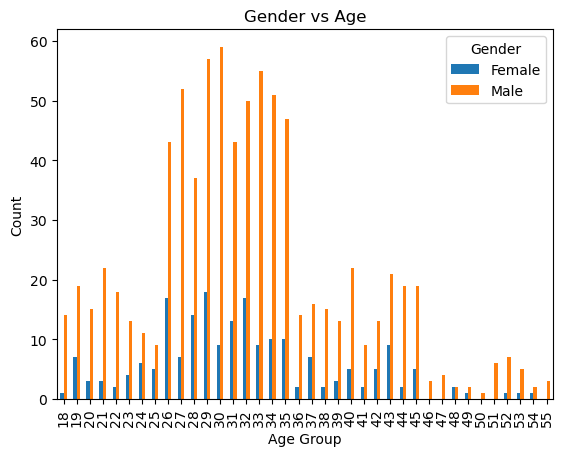

In [240]:
# bar chart of the gender vs age.
df.groupby(["AgeGrp", "Gender"]).size().unstack(fill_value=0).plot(kind="bar")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.title("Gender vs Age");

In [242]:
df.columns

Index(['AgeGrp', 'Gender', 'YrsDrive', 'DriveFreq', 'VehType', 'VehAge',
       'LastService', 'OVC', 'HESL', 'HPhone', 'HBrake', 'HDistract',
       'SleepHrs', 'TiredMonth', 'Alcohol6h', 'MedsAlert', 'DriveEnv',
       'RoadCond', 'Lighting', 'Weather', 'DriveTime', 'TrafficLvl',
       'RushHours', 'Accident5y', 'TrainingType', 'SignVis', 'County',
       'AccOccur'],
      dtype='object')

In [25]:
# group the datasets based on counties
# create a mask whereby the accidents occuring are subset
mask = (df["AccOccur"] == 1)
# new dataframe whereby all results are for accidents occurence
df_acc_occur = df[mask]
# distribution of accidents based on counties


Text(0.5, 1.0, 'Demographics of accidents vs Gender')

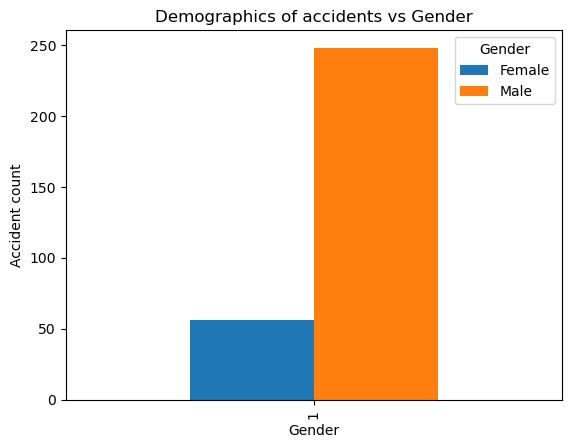

In [251]:
# what is the correaltion between the number of accidents that occured vs the gender
df_acc_occur.groupby(["AccOccur", "Gender"]).size().unstack(fill_value=0).plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Accident count")
plt.title("Demographics of accidents vs Gender")

from the above graph we can conclude that more men are involved in accidents compared to ladies 

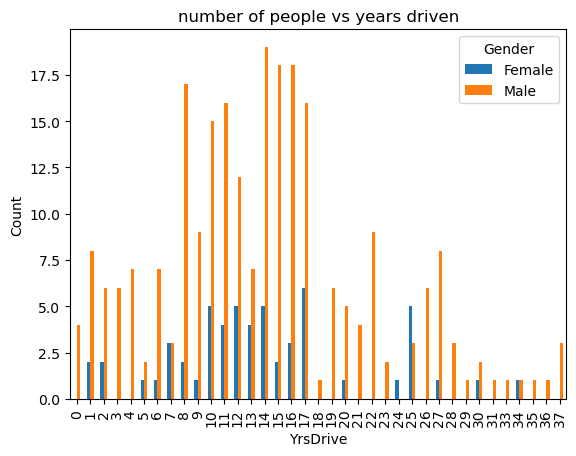

In [255]:
# years driven; the demographics of male vs female drivers based on experience
# use the whole data set to get a better analysis
df.groupby(["YrsDrive", "Gender"]).size().unstack(fill_value=0).plot(kind="bar")
plt.ylabel("Count")
plt.title("number of people vs years driven");

their are more male drivers with experience compared to female drivers

In [257]:
df_acc_occur["Gender"].value_counts(normalize=True)

Gender
Male      0.815789
Female    0.184211
Name: proportion, dtype: float64

since male drivers are 82% prone to cause accidents we can conclude that most of the features collected are directly linked to them.

plot a correlation heatmap of the numerical features in df. the target is AccOccur so it will be dropped. This is to reduce leaky features

<Axes: >

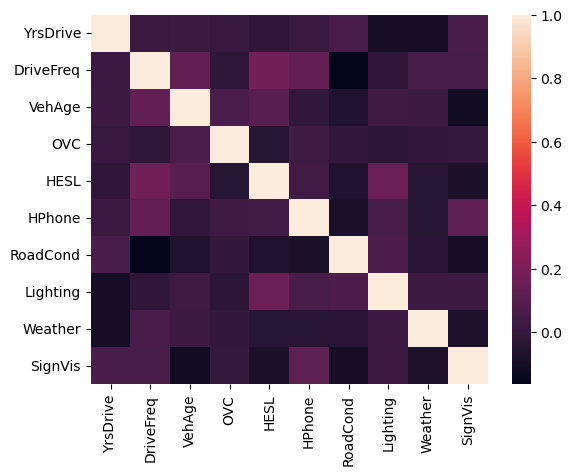

In [271]:
# Create correaltion matrix
correlation = df_acc_occur.select_dtypes("number").drop(columns=["AccOccur", "AgeGrp", "SleepHrs", "TiredMonth", "Alcohol6h", "MedsAlert"]).corr()
# plot heatmap of "correlation"
sns.heatmap(correlation)

There are no features that I need to drop

In [272]:
df.columns

Index(['AgeGrp', 'Gender', 'YrsDrive', 'DriveFreq', 'VehType', 'LastService',
       'OVC', 'HESL', 'HPhone', 'HBrake', 'HDistract', 'SleepHrs', 'Alcohol6h',
       'DriveEnv', 'RoadCond', 'Lighting', 'Weather', 'DriveTime',
       'TrafficLvl', 'Accident5y', 'TrainingType', 'SignVis', 'County',
       'AccOccur'],
      dtype='object')

Using seaborn to create a boxplot that shows the distribution of the years driven [YrsDrive] and the AccOccur

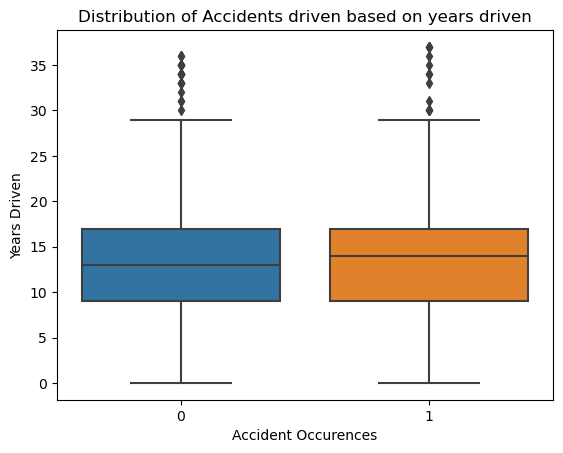

In [275]:
# create a boxplot
sns.boxplot(x="AccOccur", y="YrsDrive", data=df)
# labels
plt.xlabel("Accident Occurences")
plt.ylabel("Years Driven")
plt.title("Distribution of Accidents driven based on years driven");

the expectation was accidents mainly occur with people who are inexperienced but the boxplot shows accidents occur mainly between 10yrs and 17 yrs of experience

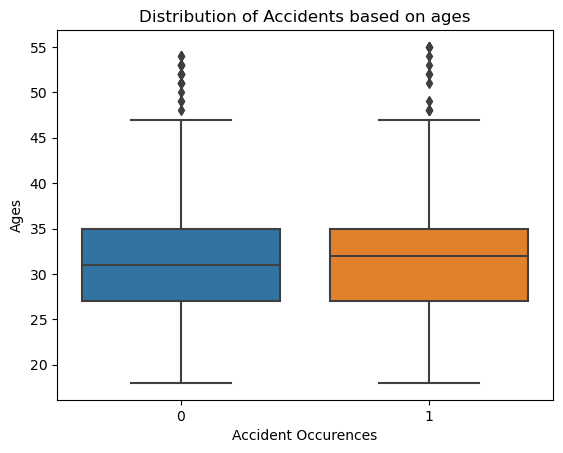

In [276]:
# box plot of age group and accident occurences
# create a boxplot
sns.boxplot(x="AccOccur", y="AgeGrp", data=df)
# labels
plt.xlabel("Accident Occurences")
plt.ylabel("Ages")
plt.title("Distribution of Accidents based on ages");

based on the boxplot shown accidents mostly occur between the ages of 28 and 33.

In [281]:
df.columns

Index(['AgeGrp', 'Gender', 'YrsDrive', 'DriveFreq', 'VehType', 'LastService',
       'OVC', 'HESL', 'HPhone', 'HBrake', 'HDistract', 'SleepHrs', 'Alcohol6h',
       'DriveEnv', 'RoadCond', 'Lighting', 'Weather', 'DriveTime',
       'TrafficLvl', 'Accident5y', 'TrainingType', 'SignVis', 'County',
       'AccOccur'],
      dtype='object')

In [302]:
majority_class_prop, minority_class_prop = df["AccOccur"].value_counts(normalize=True)
print(majority_class_prop, minority_class_prop)

0.7001972386587771 0.29980276134122286


Are accidents more prone based on the road condition. Create a pivot table of the df where the index is Road condition and the values come from the AccOccur column aggregated by the mean

In [304]:
foundation_pivot_RC = pd.pivot_table(
    df, index="RoadCond", values="AccOccur", aggfunc=np.mean).sort_values(by="AccOccur")
foundation_pivot

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7912\3379315666.py:1: FutureWarning: The provided callable <function mean at 0x000001DDEE08E340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  foundation_pivot_RC = pd.pivot_table(


,AccOccur
RoadCond,
Good,0.283019
Fair,0.302924


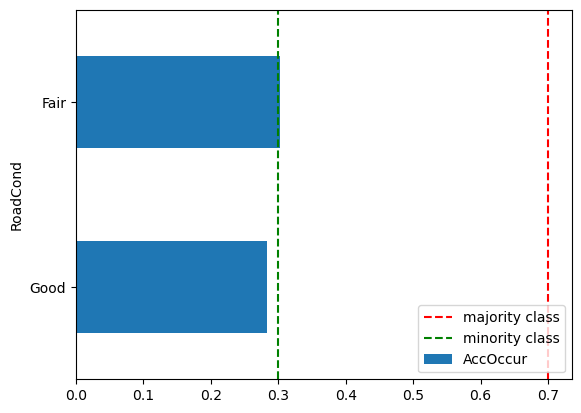

In [307]:
# plot a bar chart of the foundation table based on road conditions
foundation_pivot_RC.plot(kind="barh")
plt.axvline(
    majority_class_prop, linestyle="--", color="red", label="majority class"
)
plt.axvline(
    minority_class_prop, linestyle="--", color="green", label="minority class"
)
plt.legend(loc="lower right")

since most of the users said that accidents didn't occur, the pivot table shows that good and fair roads prevent accidents.

Are accidents more prone based on the weather. Create a pivot table of the df where the index is Road condition and the values come from the AccOccur column aggregated by the mean

In [313]:
foundation_pivot_w = pd.pivot_table(
    df, index="Weather", values="AccOccur", aggfunc=np.mean).sort_values(by="AccOccur")
foundation_pivot_w

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7912\3755621181.py:1: FutureWarning: The provided callable <function mean at 0x000001DDEE08E340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  foundation_pivot_w = pd.pivot_table(


,AccOccur
Weather,
Clear,0.286267
Dusty,0.318033
Rainy,0.341667


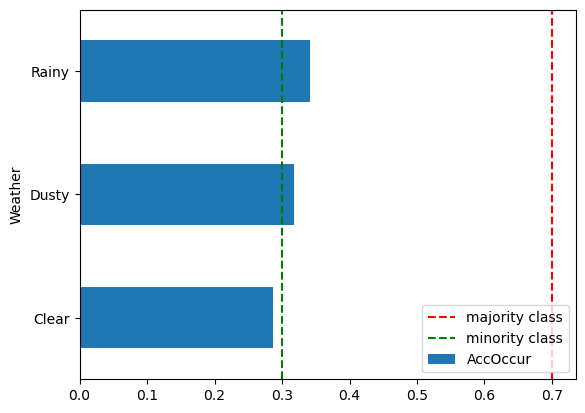

In [309]:
# plot a bar chart of the foundation table based on road conditions
foundation_pivot_w.plot(kind="barh")
plt.axvline(
    majority_class_prop, linestyle="--", color="red", label="majority class"
)
plt.axvline(
    minority_class_prop, linestyle="--", color="green", label="minority class"
)
plt.legend(loc="lower right")

since most of the users said that accidents didn't occur, the pivot table shows that clear, dusty or rainy weather rarely cause accidents which is not the case in reality since accidents occur during rainy seasons.

Are accidents more prone based on the sign visibility. Create a pivot table of the df where the index is Road condition and the values come from the AccOccur column aggregated by the mean

In [314]:
foundation_pivot_sv = pd.pivot_table(
    df, index="SignVis", values="AccOccur", aggfunc=np.mean).sort_values(by="AccOccur")
foundation_pivot_sv

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7912\1400122411.py:1: FutureWarning: The provided callable <function mean at 0x000001DDEE08E340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  foundation_pivot_sv = pd.pivot_table(


,AccOccur
SignVis,
Very poor (signs are missing or unclear),0.224490
Poor,0.273846
Adequate,0.314961
Good,0.325000
Very good (clear and easy to follow),0.344444


The pivot table shows that accidents don't occur when signs are seen.

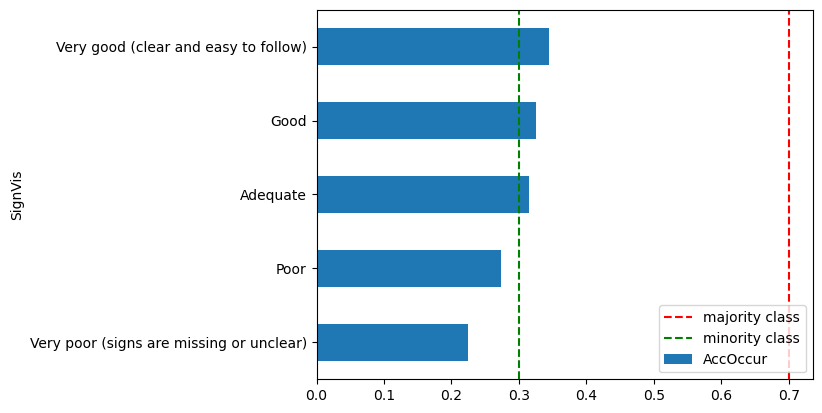

In [312]:
# plot a bar chart of the foundation table based on road conditions
foundation_pivot_sv.plot(kind="barh")
plt.axvline(
    majority_class_prop, linestyle="--", color="red", label="majority class"
)
plt.axvline(
    minority_class_prop, linestyle="--", color="green", label="minority class"
)
plt.legend(loc="lower right")

if the data was organic instead of synthetic, very poor signs or non poor signs would be an incicator of accidents.

In [24]:
df.columns

Index(['AgeGrp', 'Gender', 'YrsDrive', 'DriveFreq', 'VehType', 'OVC', 'HESL',
       'HPhone', 'HBrake', 'HDistract', 'SleepHrs', 'Alcohol6h', 'DriveEnv',
       'RoadCond', 'Lighting', 'Weather', 'DriveTime', 'TrafficLvl',
       'Accident5y', 'TrainingType', 'SignVis', 'County', 'AccOccur',
       'Latitude', 'Longitude'],
      dtype='object')

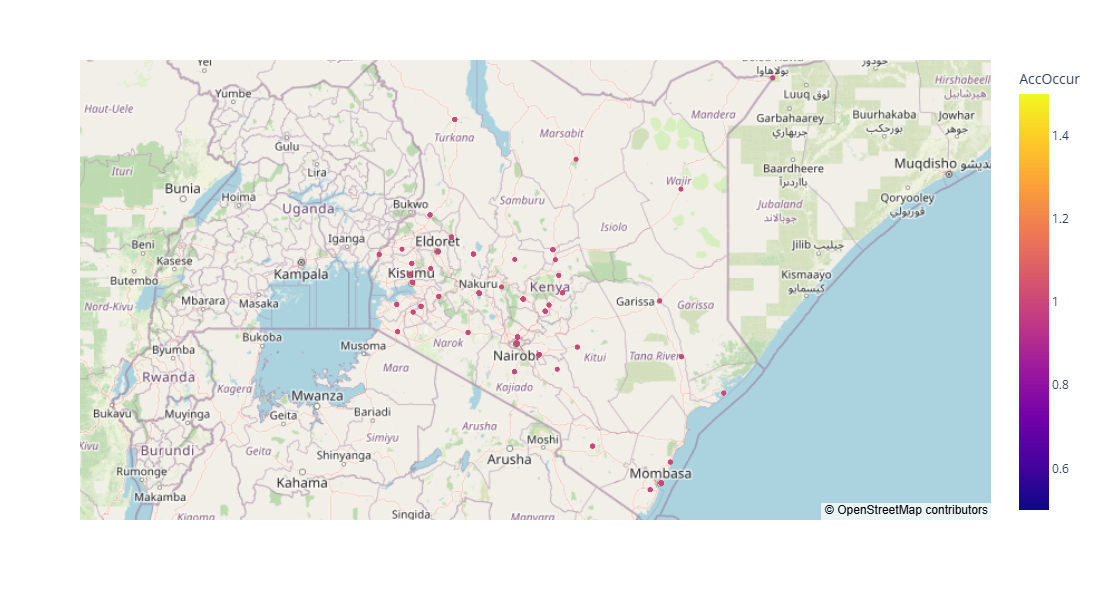

In [26]:
# using plotl express design a geo map of the distribuiton of accident occurences in the county
fig = px.scatter_mapbox(
    df_acc_occur,
    lat="Latitude",
    lon="Longitude",
    width=600,
    height=600,
    color="AccOccur",
    hover_data=["AccOccur"]
)

fig.update_layout(mapbox_style="open-street-map")

fig.show()

## Split

In [330]:
df.columns

Index(['AgeGrp', 'Gender', 'YrsDrive', 'DriveFreq', 'VehType', 'OVC', 'HESL',
       'HPhone', 'HBrake', 'HDistract', 'SleepHrs', 'Alcohol6h', 'DriveEnv',
       'RoadCond', 'Lighting', 'Weather', 'DriveTime', 'TrafficLvl',
       'Accident5y', 'TrainingType', 'SignVis', 'County', 'AccOccur'],
      dtype='object')

In [33]:
# create a feature matrix X and a target vector y. 
target = "AccOccur"
y=df[target]
X = df.drop(columns=[target, "County"])

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [341]:
print("X_train shape:", X_train.shape)

X_train shape: (811, 19)


## Build model

In [35]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline accuracy: ", round(acc_baseline, 2))

Baseline accuracy:  0.7


## Iterate

In [38]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    SimpleImputer(),
    LogisticRegression(class_weight="balanced")
)
model.fit(X_train, y_train)

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning:

lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehotencoder', ...), ('simpleimputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Gender', 'VehType', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


In [39]:
# evaluate
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = model.score(X_test, y_test)
print("The test accuracy was:", acc_test)
print("Training accuracy:", acc_train)

The test accuracy was: 0.541871921182266
Training accuracy: 0.5561035758323057


## Confusion Matrix

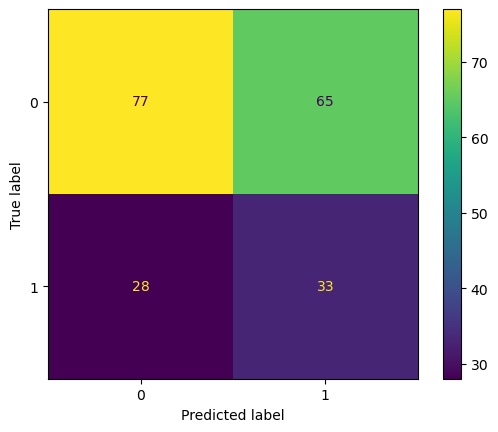

In [40]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [43]:
clr = classification_report(y_test, model.predict(X_test))
print(clr)

              precision    recall  f1-score   support

           0       0.73      0.54      0.62       142
           1       0.34      0.54      0.42        61

    accuracy                           0.54       203
   macro avg       0.54      0.54      0.52       203
weighted avg       0.61      0.54      0.56       203



# Communicate Results

In [41]:
coefficients = model.named_steps["logisticregression"].coef_[0]
features = model.named_steps["onehotencoder"].get_feature_names_out()
feat_imp = pd.Series(coefficients, index=features)
feat_imp

AgeGrp                                              0.088144
Gender_Female                                      -0.084918
Gender_Male                                         0.094852
YrsDrive                                           -0.090676
DriveFreq                                           0.024042
VehType_Car                                         0.023855
VehType_Motorcycle                                 -0.013920
OVC                                                 0.237742
HESL                                               -0.021754
HPhone                                             -0.008454
HBrake_Never                                       -0.067003
HBrake_Rarely                                       0.059660
HBrake_Sometimes                                    0.017277
HDistract_Rarely                                    0.016110
HDistract_Never                                     0.022696
HDistract_Sometimes                                -0.028871
SleepHrs                

Text(0.5, 1.0, 'Feature Importances for Accident Avoidance')

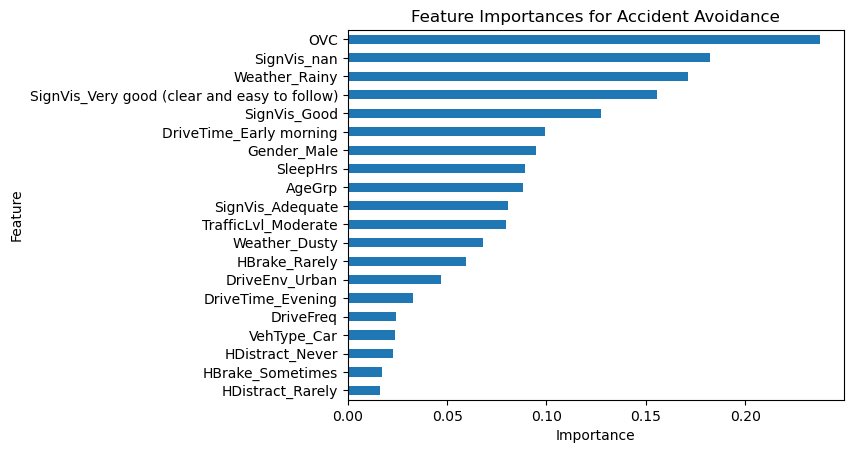

In [42]:
# create a horizontal bar chart that shows the 10 most influential coefficients for your model.
fig, ax = plt.subplots()

feat_imp.sort_values().tail(20).plot(kind="barh", ax=ax)

# label axes
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

ax.set_title("Feature Importances for Accident Avoidance")